# Window Functions

Windowing multiplies a signal frame by a bell-shaped taper before taking the FFT. Without a window, the DFT implicitly assumes the frame repeats periodically — if the frame edges don't align, this creates a **spectral leakage** artefact: energy from a strong bin spreads into adjacent bins.

Different windows trade off:
- **Main-lobe width** (frequency resolution): narrower = better resolving power
- **Side-lobe level** (leakage suppression): lower side lobes = less contamination from nearby strong tones

| Function | Description |
| --- | --- |
| `apply_window` | Multiply a signal frame by the named window function. Supported windows: `"rectangular"`, `"hann"`, `"hamming"`, `"blackman"`. Returns the windowed frame. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.time_segment import apply_window

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Four window functions applied to a 1024-sample frame of a 440.7 Hz sine (deliberately off-bin to maximise leakage).

**2 × 4 grid (one column per window type):**

**Top row — windowed waveforms:**
- **Rectangular:** flat envelope; no tapering; full amplitude at the edges — creates the worst leakage
- **Hann:** smooth raised-cosine taper; edges fade to zero — standard choice for STFT
- **Hamming:** similar cosine taper to Hann but with a small DC offset; slightly higher side lobes than Hann but wider main lobe
- **Blackman:** very aggressive tapering; edges approach zero faster — best side-lobe suppression

**Bottom row — magnitude spectra in dB:**
- **Rectangular:** sharp main lobe (1 bin wide) but **high side lobes (~−13 dB)** — neighbouring bins are significantly polluted
- **Hann:** main lobe ~2 bins wide; side lobes ~−32 dB; a good trade-off for most audio analysis
- **Hamming:** side lobes ~−43 dB at the cost of a slightly wider main lobe
- **Blackman:** side lobes ~−74 dB — excellent leakage suppression for resolving tones close together; main lobe ~4 bins wide

**Rule of thumb:** use Hann for general STFT work; use Blackman when trying to detect a weak tone near a strong one.


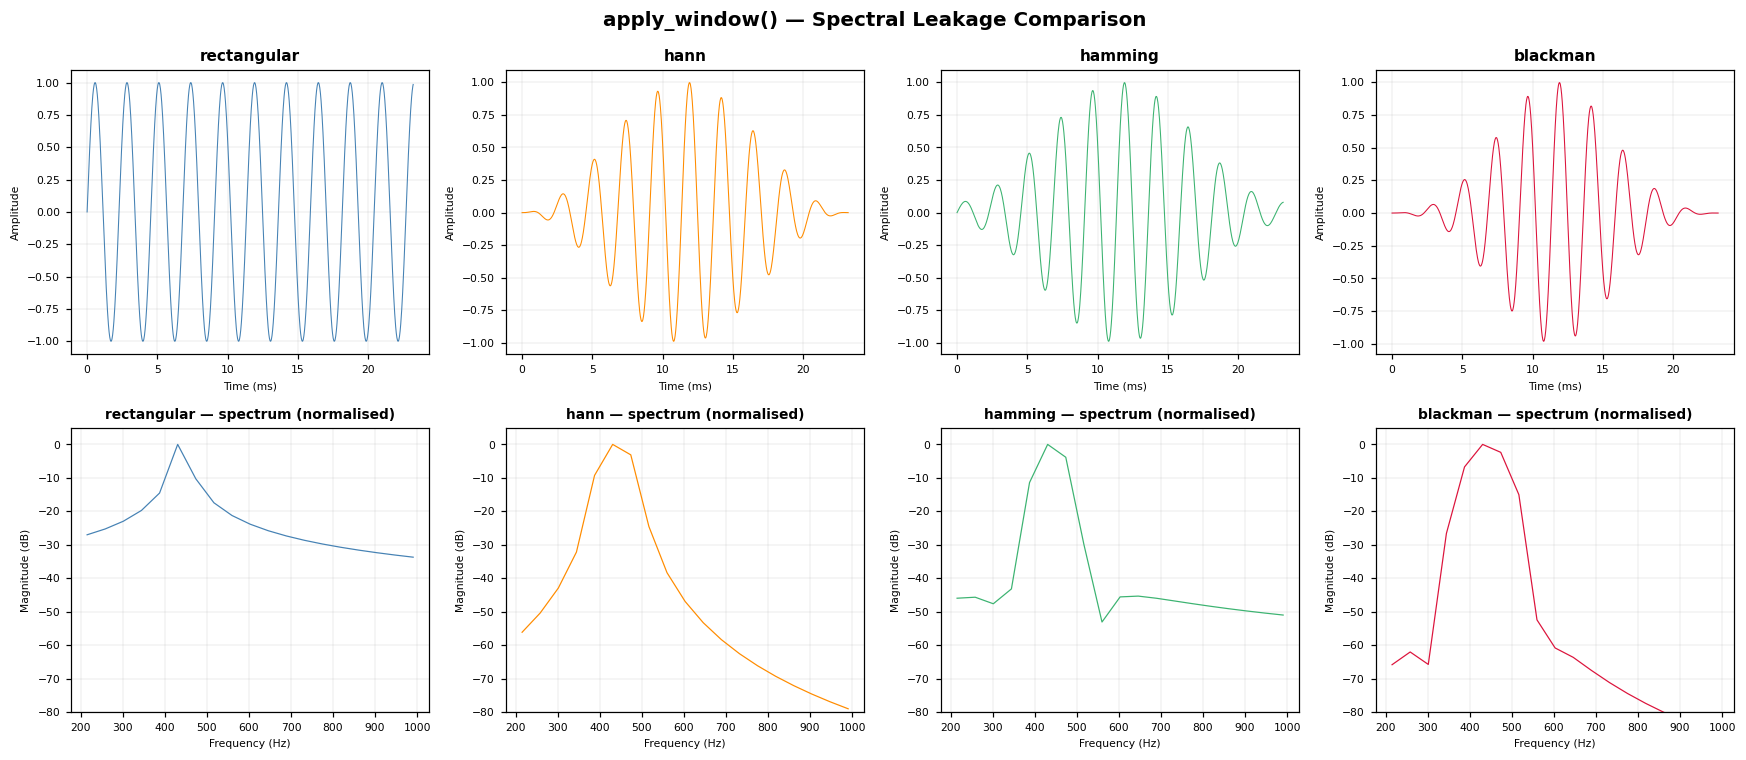

In [2]:
FS = 44100
FREQ = 440.0
FRAME = 1024

# Frequency not aligned to a bin — maximises leakage
FREQ_MISALIGNED = 440.7
t = np.arange(FRAME) / FS
sig = np.sin(2 * np.pi * FREQ_MISALIGNED * t)

WINDOWS = ["rectangular", "hann", "hamming", "blackman"]
COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

freqs = np.fft.rfftfreq(FRAME, d=1.0 / FS)

fig, axes = plt.subplots(2, len(WINDOWS), figsize=(16, 7))

for col, (wtype, color) in enumerate(zip(WINDOWS, COLORS)):
    windowed = apply_window(sig, window_type=wtype)
    t_ms = np.arange(FRAME) / FS * 1000

    axes[0, col].plot(t_ms, windowed, linewidth=0.7, color=color)
    axes[0, col].set_title(f"{wtype}", fontsize=10, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].tick_params(labelsize=7)
    axes[0, col].grid(True, linewidth=0.3, alpha=0.5)

    spectrum = np.abs(np.fft.rfft(windowed))
    db = 20 * np.log10(spectrum + 1e-12)
    db -= db.max()  # normalise to 0 dB peak
    mask = (freqs > 200) & (freqs < 1000)
    axes[1, col].plot(freqs[mask], db[mask], linewidth=0.8, color=color)
    axes[1, col].set_title(f"{wtype} — spectrum (normalised)", fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Frequency (Hz)", fontsize=7)
    axes[1, col].set_ylabel("Magnitude (dB)", fontsize=7)
    axes[1, col].set_ylim(-80, 5)
    axes[1, col].tick_params(labelsize=7)
    axes[1, col].grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("apply_window() — Spectral Leakage Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()